# **1. Check number of casual riders and members**

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np

df = pd.read_csv('../data/1.casual_member.csv')


In [31]:
df

,member_casual,counted,percent
0,casual,2112103,35.64
1,member,3814650,64.36


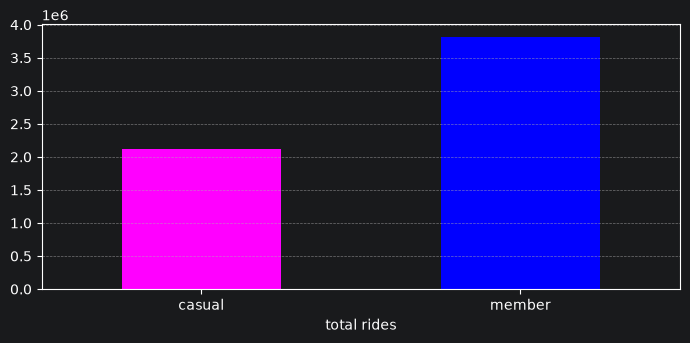

In [32]:
ax = df.set_index('member_casual')['counted'].plot(kind='bar', figsize=(7, 4), color=['magenta', 'blue'] )
plt.xlabel('total rides')
plt.tight_layout()
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.savefig('casual_member.png', dpi=150)
plt.show()

# **2. Check who drives how much on which day**

In [33]:
df = pd.read_csv('../data/5.rides_a_day_casual_member.csv')

pivot = df.pivot(index='day_of_week', columns='member_casual', values='total_rides')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(weekday_order)

In [34]:
pivot

member_casual,casual,member
day_of_week,,
Monday,245285,535526
Tuesday,244497,618675
Wednesday,235036,602451
Thursday,264025,608924
Friday,330712,559810
Saturday,445387,483443
Sunday,347161,405821


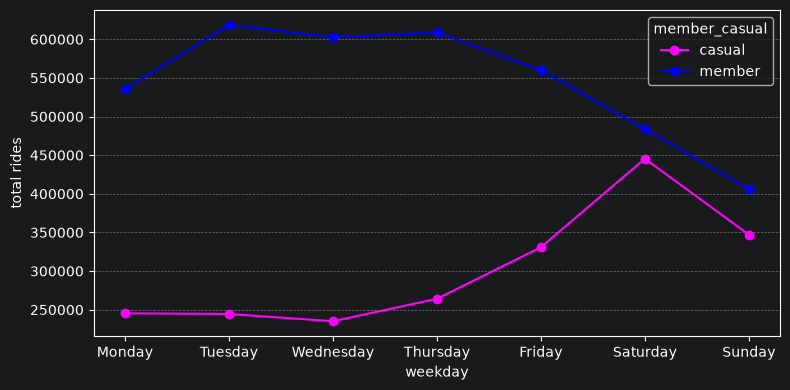

In [35]:
pivot.plot(kind='line', figsize=(8, 4), color=['magenta', 'blue'], marker='o')
plt.ylabel('total rides')
plt.xlabel('weekday')
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.savefig('rides_by_weekday.png', dpi=150)
plt.show()

## Statistical analysis

In [36]:
df = pd.read_csv('../data/5.rides_a_day_casual_member.csv')

contingency_table = df.pivot(index='day_of_week', columns='member_casual', values='total_rides')
print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

print(f"Chi²-Statistic: {chi2:.2f}")
print(f"p-Value: {p_value}")
print(f"Degrees of freedom: {dof}")
print(f"Cramér's V: {cramers_v:.4f}")

member_casual  casual  member
day_of_week                  
Friday         330712  559810
Monday         245285  535526
Saturday       445387  483443
Sunday         347161  405821
Thursday       264025  608924
Tuesday        244497  618675
Wednesday      235036  602451
Chi²-Statistic: 156443.80
p-Value: 0.0
Degrees of freedom: 6
Cramér's V: 0.1625


# **3. Check who drives how much at which time of the day**

In [37]:
df = pd.read_csv('../data/7.hour_of_day_casual_member.csv')

pivot = df.pivot(index='hour_of_day', columns='member_casual', values='total_rides')

In [38]:
pivot

member_casual,casual,member
hour_of_day,,
0,43111,35220
1,28120,21479
2,18247,12859
3,10171,8372
4,8213,9392
5,12864,37010
6,28318,108296
7,52055,215413
8,74722,278840


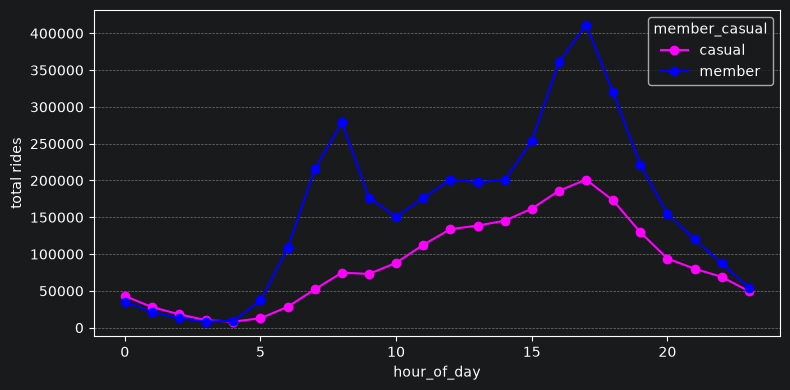

In [39]:
pivot.plot(kind='line', figsize=(8, 4), color=['magenta', 'blue'], marker='o')
plt.ylabel('total rides')
plt.xlabel('hour_of_day')
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.savefig('rides_by_time_of_day.png', dpi=150)
plt.show()

## Statistical analysis

In [40]:
df = pd.read_csv('../data/7.hour_of_day_casual_member.csv')

contingency_table = df.pivot(index='hour_of_day', columns='member_casual', values='total_rides')
print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

print(f"Chi²-Statistic: {chi2:.2f}")
print(f"p-Value: {p_value}")
print(f"Degrees of freedom: {dof}")
print(f"Cramér's V: {cramers_v:.4f}")

member_casual  casual  member
hour_of_day                  
0               43111   35220
1               28120   21479
2               18247   12859
3               10171    8372
4                8213    9392
5               12864   37010
6               28318  108296
7               52055  215413
8               74722  278840
9               73086  176520
10              88135  150928
11             112678  176281
12             133913  201125
13             138695  197839
14             145339  200475
15             161703  254106
16             186052  360904
17             201168  411479
18             172826  319773
19             129774  221639
20              93965  154530
21              80184  120194
22              69072   87450
23              49692   54526
Chi²-Statistic: 149919.35
p-Value: 0.0
Degrees of freedom: 23
Cramér's V: 0.1590


# **4. Check who drives how much in which month**

In [41]:
df = pd.read_csv('../data/4.rides_month_casual_member.csv')

pivot = df.pivot(index='month', columns='member_casual', values='total_rides')
month_order = ['June 2025', 'July 2025', 'August 2025', 'September 2025', 'October 2025', 'November 2025', 'December 2025', 'January 2026', 'February 2026', 'March 2026', 'April 2026', 'May 2026', 'June 2026']
pivot = pivot.reindex(month_order)

In [42]:
pivot

member_casual,casual,member
month,,
June 2025,56,27
July 2025,322505,439965
August 2025,337246,452355
September 2025,264772,449202
October 2025,223569,421921
November 2025,98871,257292
December 2025,28005,112415
January 2026,24656,112933
February 2026,41088,160251


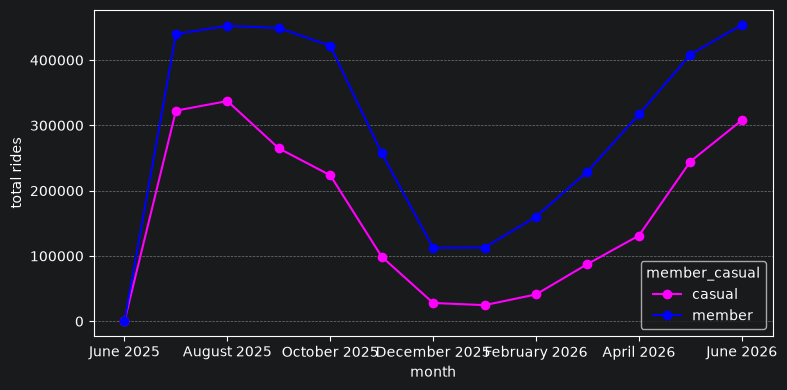

In [43]:
pivot.plot(kind='line', figsize=(8, 4), color=['magenta', 'blue'], marker='o')
plt.ylabel('total rides')
plt.xlabel('month')
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.savefig('rides_by_month.png', dpi=150)
plt.show()

## Statistical analysis

In [44]:
df = pd.read_csv('../data/4.rides_month_casual_member.csv')

contingency_table = df.pivot(index='month', columns='member_casual', values='total_rides')
print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

print(f"Chi²-Statistic: {chi2:.2f}")
print(f"p-Value: {p_value}")
print(f"Degrees of freedom: {dof}")
print(f"Cramér's V: {cramers_v:.4f}")

member_casual   casual  member
month                         
April 2026      131223  316675
August 2025     337246  452355
December 2025    28005  112415
February 2026    41088  160251
January 2026     24656  112933
July 2025       322505  439965
June 2025           56      27
June 2026       307827  453983
March 2026       87631  229121
May 2026        244654  408510
November 2025    98871  257292
October 2025    223569  421921
September 2025  264772  449202
Chi²-Statistic: 121968.15
p-Value: 0.0
Degrees of freedom: 12
Cramér's V: 0.1435


# **5. Check which user type uses which bike type**

In [45]:
df = pd.read_csv('../data/6.rideable_type_casual_member.csv')

pivot = df.pivot(index='member_casual', columns='rideable_type', values='total_rides')

In [46]:
pivot

rideable_type,classic_bike,electric_bike
member_casual,,
casual,630406,1481697
member,1283903,2530747


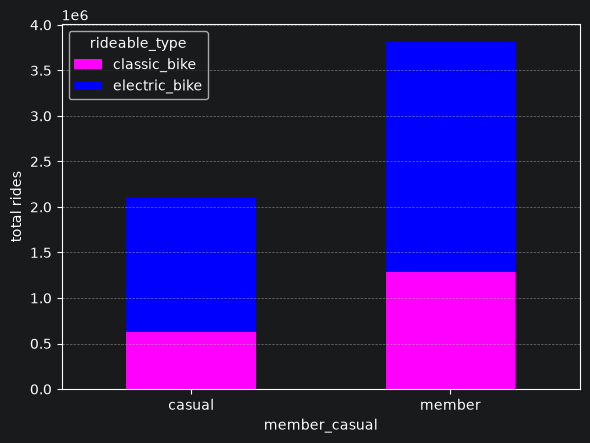

In [47]:
pivot.plot(kind='bar', stacked=True, figsize=(6, 5), color=['magenta', 'blue'])
plt.ylabel('total rides')
plt.tight_layout()
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.savefig('user_type_bike_type.png', dpi=150)
plt.show()

## Statistical analysis

In [48]:
df = pd.read_csv('../data/6.rideable_type_casual_member.csv')

contingency_table = df.pivot(index='member_casual', columns='rideable_type', values='total_rides')
print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

print(f"Chi²-Statistic: {chi2:.2f}")
print(f"p-Value: {p_value}")
print(f"Degrees of freedom: {dof}")
print(f"Cramér's V: {cramers_v:.4f}")

rideable_type  classic_bike  electric_bike
member_casual                             
casual               630406        1481697
member              1283903        2530747
Chi²-Statistic: 9023.46
p-Value: 0.0
Degrees of freedom: 1
Cramér's V: 0.0390


# **6. Relationship between ride duration and user type**

In [49]:
df = pd.read_csv('../data/9.sample_ride_length_member_casual.csv')

df

,member_casual,ride_length_minutes
0,member,44
1,member,37
2,member,37
3,casual,62
4,member,83
...,...,...
119001,member,30
119002,member,30
119003,member,30
119004,casual,30


## Statistical analysis

In [50]:
from scipy import stats
casual = df[df['member_casual'] == 'casual']['ride_length_minutes']
member = df[df['member_casual'] == 'member']['ride_length_minutes']

t_stat, p_value = stats.ttest_ind(casual, member, equal_var=False)
print(f"t-Statistik: {t_stat:.2f}, "f"p-Wert: {p_value:.4f}")

t-Statistik: 34.66, p-Wert: 0.0000


In [51]:
print("Min Casual:", casual.min())
print("Min Member:", member.min())
print("Max Casual:", casual.max())
print("Max Member:", member.max())
print("Mean Casual:", casual.mean())
print("Mean Member:", member.mean())
print("Median Casual:", casual.median())
print("Median Member:", member.median())

Min Casual: 0
Min Member: 0
Max Casual: 1439
Max Member: 1248
Mean Casual: 17.94789370125406
Mean Member: 11.496635122294105
Median Casual: 11.0
Median Member: 8.0


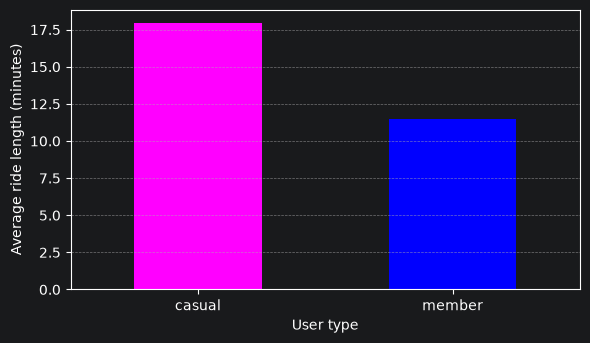

In [52]:
avg_duration = df.groupby("member_casual")["ride_length_minutes"].mean()

plt.figure(figsize=(6,4))
avg_duration.plot(kind="bar", color=["magenta", "blue"])

plt.xlabel("User type")
plt.ylabel("Average ride length (minutes)")
plt.tight_layout()
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.savefig('duration_type.png', dpi=150)
plt.show()